Selected Sensors: {1, 2}


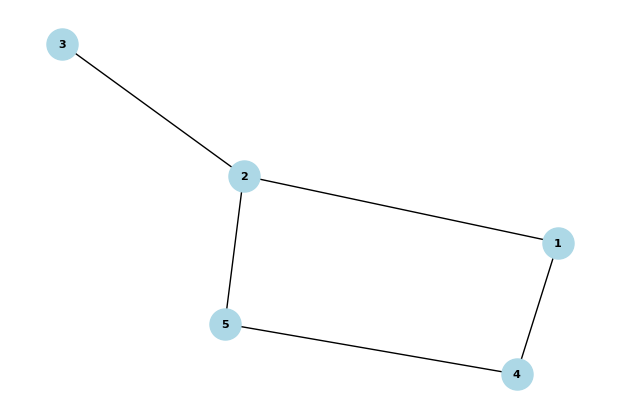

In [8]:
import heapq
import networkx as nx
import matplotlib.pyplot as plt

def outbreak_influence(G, S):
    influenced = set(S)
    for node in S:
        influenced.update(G.neighbors(node))
    return len(influenced)


def CELF_networkx(G, k):
    S = set()
    heap = []
    iteration = 0

    # Initial gains
    for node in G.nodes():
        gain = outbreak_influence(G, {node})
        heapq.heappush(heap, (-gain, node, 0))

    while len(S) < k:
        neg_gain, node, last_update = heapq.heappop(heap)

        if last_update == iteration:
            S.add(node)
            iteration += 1
        else:
            new_gain = outbreak_influence(G, S | {node}) - outbreak_influence(G, S)
            heapq.heappush(heap, (-new_gain, node, iteration))

    return S

G = nx.Graph()
G.add_edges_from([(1,2), (2,3), (1,4), (2,5), (4,5)])
plt.figure(figsize=(6, 4))
nx.draw(G, with_labels=True, node_size=500, node_color="lightblue", font_size=8, font_weight="bold", edge_color="black"
)
sensors = CELF_networkx(G, k=2)
print("Selected Sensors:", sensors)